# Modelisation Machine Learning

Ce notebook montre l’etape de modélisation qui suit l’EDA et le preprocessing. Il utilise les tables preprocessés stockés sur SUPABASE\public et construit un pipeline Scikit-learn complet pour le preprocessing et la modélisation.

## 1. Imports et configuration

In [2]:
import os
import pandas as pd
import numpy as np
import json
import joblib
import seaborn as sns
import matplotlib.pyplot as plt


from supabase import create_client
from pandas.api.types import is_string_dtype

# Préprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# Validation croisée
from sklearn.model_selection import cross_val_score
from typing import Any
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report,roc_auc_score
from sklearn.metrics import confusion_matrix

#Visualisation
from sklearn.model_selection import learning_curve

from pathlib import Path
from datetime import datetime

ROOT = Path.cwd()


## 2. Chargement des donnees preprocessées

In [2]:
# Connexion Supabase
url = os.environ.get("SUPABASE_URL")
key = os.environ.get("SUPABASE_SERVICE_ROLE_KEY")
supabase = create_client(url, key)

def load_table(table_name, batch_size=1000):
    rows = []
    start = 0

    while True:
        end = start + batch_size - 1
        batch = supabase.table(table_name).select("*").range(start, end).execute()

        if not batch.data:
            break

        rows.extend(batch.data)
        start += batch_size

    df = pd.DataFrame(rows)

    print(f"Table {table_name} chargée : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
    return df

X_train = load_table("X_train")
X_test  = load_table("X_test")
y_train = load_table("y_train")
y_test  = load_table("y_test")

y_train = y_train.iloc[:, 0]
y_test = y_test.iloc[:, 0]


Table X_train chargée : 12,425 lignes × 21 colonnes
Table X_test chargée : 3,107 lignes × 21 colonnes
Table y_train chargée : 12,425 lignes × 1 colonnes
Table y_test chargée : 3,107 lignes × 1 colonnes


## 3. Construction du pipeline de preprocessing

In [3]:
def build_preprocesseur(df: pd.DataFrame):
    # Colonnes catégorielles définies manuellement
    #categorical_cols = ['PTGENDER', 'PTMARRY','PTHAND']
   
    # Colonnes numériques définies manuellement #
    numeric_cols = ["CDGLOBAL", "CDMEMORY", "CDRSB", "TOTSCORE", "TOTAL13", "CDJUDGE", "MMSCORE", "VSWEIGHT", "RtensionA", "VSPULSE", "CDHOME", "VSBPSYS", "pressionP", "CDCOMMUN", "VSBPDIA", "ST112SV", "ST120SV", "ST101SV", "ST125SV", "WORD2DL", "IMC"]
    
    # Pipeline numérique
    pipeline_numerique = Pipeline(steps=[
        ('imputation', SimpleImputer(strategy='median')),
        ('normalisation', StandardScaler()),
    ])

    # Pipeline catégoriel
    #pipeline_categoriel = Pipeline(steps=[
    #    ('imputation', SimpleImputer(strategy='most_frequent')),
    #    ('encodage', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
    #])

    # Assemblage des transformations
    transformations = []
    if numeric_cols:
        transformations.append(('numerique', pipeline_numerique, numeric_cols))

    preprocesseur = ColumnTransformer(transformers=transformations,remainder='drop'
    )

    return preprocesseur, numeric_cols

preprocesseur, numeric_cols = build_preprocesseur(X_train)

print("Colonnes numériques :", numeric_cols)
#print("Colonnes catégorielles :", categorical_cols)
print(preprocesseur)




Colonnes numériques : ['CDGLOBAL', 'CDMEMORY', 'CDRSB', 'TOTSCORE', 'TOTAL13', 'CDJUDGE', 'MMSCORE', 'VSWEIGHT', 'RtensionA', 'VSPULSE', 'CDHOME', 'VSBPSYS', 'pressionP', 'CDCOMMUN', 'VSBPDIA', 'ST112SV', 'ST120SV', 'ST101SV', 'ST125SV', 'WORD2DL', 'IMC']
ColumnTransformer(transformers=[('numerique',
                                 Pipeline(steps=[('imputation',
                                                  SimpleImputer(strategy='median')),
                                                 ('normalisation',
                                                  StandardScaler())]),
                                 ['CDGLOBAL', 'CDMEMORY', 'CDRSB', 'TOTSCORE',
                                  'TOTAL13', 'CDJUDGE', 'MMSCORE', 'VSWEIGHT',
                                  'RtensionA', 'VSPULSE', 'CDHOME', 'VSBPSYS',
                                  'pressionP', 'CDCOMMUN', 'VSBPDIA', 'ST112SV',
                                  'ST120SV', 'ST101SV', 'ST125SV', 'WORD2DL',
               

## 4. Construction des pipelines de modèles

In [10]:
def build_model_pipelines(preprocessor: ColumnTransformer) -> dict[str, Pipeline]:
    return {
        'logistic_regression': Pipeline(steps=[('preprocessor', preprocessor), ('classifier', LogisticRegression(max_iter=1200, random_state=42))]),
        'random_forest': Pipeline(steps=[('preprocessor', preprocessor), ('classifier', RandomForestClassifier(n_estimators=100,max_depth=10,min_samples_leaf=20,max_features='sqrt', random_state=42, n_jobs=-1))]),
        'hist_gradient_boosting': Pipeline(steps=[('preprocessor', preprocessor), ('classifier', HistGradientBoostingClassifier(random_state=42))]),
    }

pipelines = build_model_pipelines(preprocesseur)
print('pipelines:', list(pipelines.keys()))

pipelines: ['logistic_regression', 'random_forest', 'hist_gradient_boosting']


## 5. Comparaison des modèles avec validation croisee

In [11]:
def compare_models(models: dict[str, Pipeline], x_train: pd.DataFrame, y_train: pd.Series) -> dict[str, dict[str, float]]:
    results = {}
    for name, pipeline in models.items():
        scores = cross_val_score(pipeline, x_train, y_train, cv=5, scoring='f1', n_jobs=-1)
        results[name] = {
            'mean_f1': float(scores.mean()),
            'std_f1': float(scores.std()),
            'n_splits': len(scores),
        }
    return results

comparison = compare_models(pipelines, X_train, y_train)
for model_name, stats in comparison.items():
    print(f"{model_name}: mean_f1={stats['mean_f1']:.4f}, std_f1={stats['std_f1']:.4f}")

logistic_regression: mean_f1=0.9137, std_f1=0.0026
random_forest: mean_f1=0.9193, std_f1=0.0051
hist_gradient_boosting: mean_f1=0.9184, std_f1=0.0042


## 6. Selection et entrainement du meilleur modele

In [12]:
best_name = max(comparison, key=lambda n: comparison[n]['mean_f1'])
best_pipeline = pipelines[best_name]
print('best model:', best_name)

best_pipeline.fit(X_train, y_train)
print('best pipeline trained')

best model: random_forest
best pipeline trained


## 7. Evaluation sur le jeu de test

In [13]:
def evaluate_pipeline(model: Pipeline, x_test: pd.DataFrame, y_test: pd.Series) -> dict[str, Any]:
    y_pred = model.predict(x_test)
    y_proba = None
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(x_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_proba = model.decision_function(x_test)

    metrics = {
        'accuracy': float(accuracy_score(y_test, y_pred)),
        'precision': float(precision_score(y_test, y_pred, zero_division=0)),
        'recall': float(recall_score(y_test, y_pred, zero_division=0)),
        'f1_score': float(f1_score(y_test, y_pred, zero_division=0)),
    }

    if y_proba is not None and len(np.unique(y_test)) == 2:
        try:
            metrics['roc_auc'] = float(roc_auc_score(y_test, y_proba))
        except ValueError:
            metrics['roc_auc'] = None
    else:
        metrics['roc_auc'] = None

    metrics['classification_report'] = classification_report(y_test, y_pred, zero_division=0)
    return metrics

metrics = evaluate_pipeline(best_pipeline, X_test, y_test)
for key, value in metrics.items():
    if key == 'classification_report':
        print('\nClassification report:\n', value)
    else:
        print(f'{key}: {value}')

accuracy: 0.9021564209848729
precision: 0.9141519250780437
recall: 0.9266877637130801
f1_score: 0.9203771608171818
roc_auc: 0.9636069416425384

Classification report:
               precision    recall  f1-score   support

           0       0.88      0.86      0.87      1211
           1       0.91      0.93      0.92      1896

    accuracy                           0.90      3107
   macro avg       0.90      0.90      0.90      3107
weighted avg       0.90      0.90      0.90      3107



## 8. Matrice de confusion

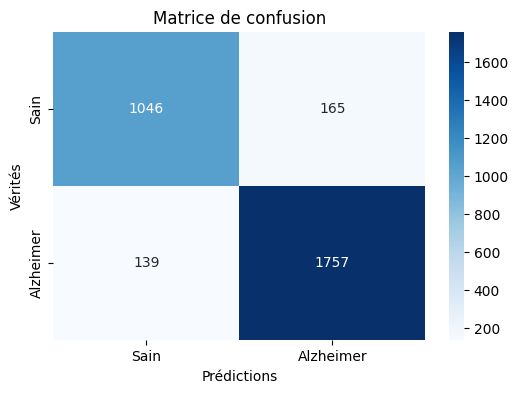

In [14]:
# Prédictions
y_pred = best_pipeline.predict(X_test)

# Matrice
cm = confusion_matrix(y_test, y_pred)

# Affichage
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sain', 'Alzheimer'],
            yticklabels=['Sain', 'Alzheimer'])
plt.xlabel('Prédictions')
plt.ylabel('Vérités')
plt.title('Matrice de confusion')
plt.show()


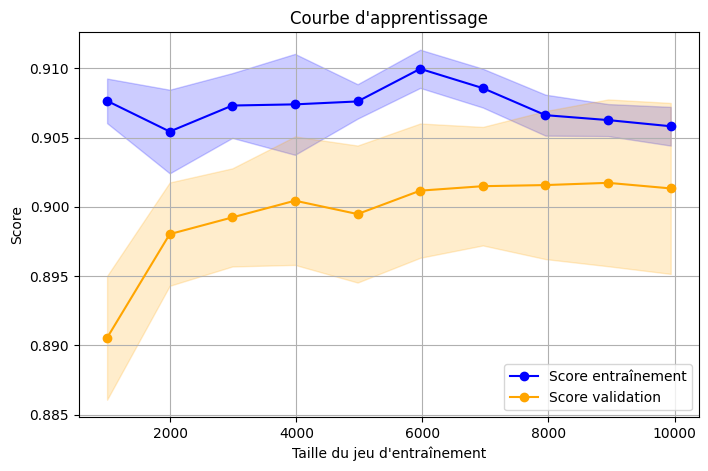

In [15]:
def plot_learning_curve(model, X, y, cv=5, scoring='accuracy'):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, scoring=scoring, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10)
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    test_mean = test_scores.mean(axis=1)
    test_std = test_scores.std(axis=1)

    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Score entraînement')
    plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Score validation')

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                     alpha=0.2, color='blue')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                     alpha=0.2, color='orange')

    plt.title("Courbe d'apprentissage")
    plt.xlabel("Taille du jeu d'entraînement")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.show()

# Exemple d'utilisation :
plot_learning_curve(best_pipeline, X_train, y_train)


## 8. Sauvegarde du modele

In [17]:
def save_model(model: Pipeline, metrics: dict[str, Any], name: str) -> dict[str, str]:
    models_dir = ROOT / 'models'
    models_dir.mkdir(exist_ok=True)
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    model_path = models_dir / f'{name}_{timestamp}.pkl'
    metadata_path = models_dir / f'{name}_{timestamp}_metadata.json'

    joblib.dump(model, model_path)
    metadata = {
        'name': name,
        'timestamp': timestamp,
        'model_path': str(model_path),
        'metrics': metrics,
    }
    metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')
    return {'model_path': str(model_path), 'metadata_path': str(metadata_path)}

save_paths = save_model(best_pipeline, metrics, best_name)
print('Model saved to:', save_paths['model_path'])
print('Metadata saved to:', save_paths['metadata_path'])

Model saved to: c:\Users\Magalie\donneesMagalie\formationM2i\programme python\Alzheimer_projet_jupyter\models\random_forest_20260506_231655.pkl
Metadata saved to: c:\Users\Magalie\donneesMagalie\formationM2i\programme python\Alzheimer_projet_jupyter\models\random_forest_20260506_231655_metadata.json


## 9. Inference sur un nouvel exemple

In [9]:
#best_pipeline = joblib.load("models/random_forest_20260510_165244.pkl")

# Exemple d'inference avec un nouveau patient
new_sample = pd.DataFrame([
    {
        'IMC': 33.30,
        'CDRSB': 0,
        'CDHOME': 0,
        'CDJUDGE': 0,
        'MMSCORE': 29,
        'ST101SV': 1819.45,
        'ST112SV': 4184.10,
        'ST120SV': 6224,
        'ST125SV': 24.50,
        'TOTAL13': 20,
        'VSBPDIA': 64,
        'VSBPSYS': 150,
        'VSPULSE': 64,
        'WORD2DL': 0,
        'CDCOMMUN': 0,
        'CDGLOBAL': 0,
        'CDMEMORY': 0,
        'TOTSCORE': 12,
        'VSWEIGHT': 94,
        'RtensionA': 2.34,
        'pressionP': 86,
    }
])


prediction = best_pipeline.predict(new_sample)
probability = None
if hasattr(best_pipeline, 'predict_proba'):
    probability = best_pipeline.predict_proba(new_sample)[0, 1]

print('Prediction:', int(prediction[0]))
if probability is not None:
    print('Confidence probability:', float(probability))

Prediction: 0
Confidence probability: 0.20398287256617517
